test
Filename: C:\Users\nikli\Downloads\Comp Astro Project\lco_data-20260503-4\lco_data-20260503-4\lscnrs01-fa09-20240501-0017-e92-1d.fits.fz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     215   ()      
  1  SPECTRUM      1 BinTableHDU     39   139R x 11C   [K, K, K, 4096D, 4096D, 4096D, 4096D, 4096D, 4096B, 4096D, 4096D]   
  2  CCF           1 BinTableHDU     18   21R x 3C   [K, 7997D, 7997D]   
ColDefs(
    name = 'id'; format = 'K'
    name = 'order'; format = 'K'
    name = 'fiber'; format = 'K'
    name = 'wavelength'; format = '4096D'; dim = '(4096)'
    name = 'flux'; format = '4096D'; dim = '(4096)'
    name = 'uncertainty'; format = '4096D'; dim = '(4096)'
    name = 'blaze'; format = '4096D'; dim = '(4096)'
    name = 'blaze_error'; format = '4096D'; dim = '(4096)'
    name = 'mask'; format = '4096B'; dim = '(4096)'
    name = 'normflux'; format = '4096D'; dim = '(4096)'
    name = 'normuncertainty'; format = '4096D'; dim =

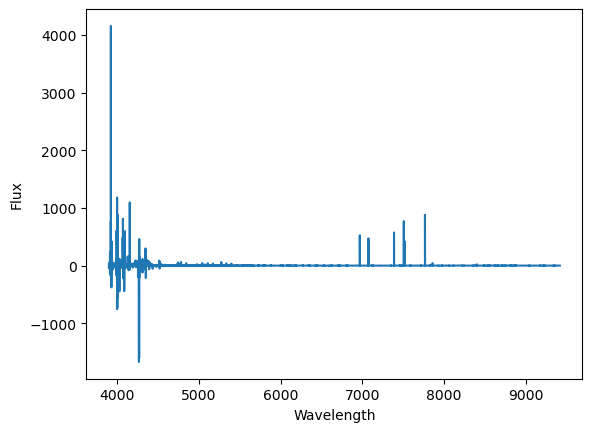

In [44]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
print("test")
hdul = fits.open(r"C:\Users\nikli\Downloads\Comp Astro Project\lco_data-20260503-4\lco_data-20260503-4\lscnrs01-fa09-20240501-0017-e92-1d.fits.fz")
hdul.info()
spec = hdul[1]
print(spec.columns)
data = hdul[1].data

allWavelengths = []
allNormFlux = []
for row in data:
    if row['fiber'] == 1:
        continue
    m = row['mask'] == 0
    good = (
        m &
        np.isfinite(row['normflux']) &
        np.isfinite(row['wavelength']) 
    )
    allWavelengths.append(row['wavelength'][good])
    allNormFlux.append(row['normflux'][good])

#allWavelengths = np.concatenate(allWavelengths)
#allNormFlux = np.concatenate(allNormFlux)
ordering = np.argsort(allWavelengths)
allWavelengths = allWavelengths[ordering]
allNormFlux = allNormFlux[ordering]
print(allNormFlux)

plt.plot(allWavelengths, allNormFlux)
plt.xlabel("Wavelength")
plt.ylabel("Flux")
plt.show()

In [1]:
import sys
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

In [6]:
def sigmaclipping(wavelengths,fluxes , alpha, tolerance, maxIterations):
    clippedFluxes = fluxes.copy()
    clippedWavelengths = wavelengths.copy()
    iteration = 0
    while(iteration < maxIterations):
        median = np.median(clippedFluxes)
        std = np.std(clippedFluxes)
        clippingMask = np.abs(clippedFluxes - median) < alpha * std
        newClippedFluxes = clippedFluxes[clippingMask]
        newClippedWavelengths = clippedWavelengths[clippingMask]
        
        if(std -  np.std(newClippedFluxes) < tolerance):
            clippedFluxes = newClippedFluxes
            clippedWavelengths = newClippedWavelengths
            break
            
        clippedFluxes = newClippedFluxes
        clippedWavelengths = newClippedWavelengths
        
        iteration = iteration +1
        
    return clippedWavelengths, clippedFluxes
    

Filename: C:\Users\nikli\Downloads\Comp Astro Project\lco_data-20260503-4 (2)\lco_data-20260503-4\tlvnrs04-fa18-20240120-0016-e92-1d.fits.fz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     215   ()      
  1  SPECTRUM      1 BinTableHDU     39   136R x 11C   [K, K, K, 4096D, 4096D, 4096D, 4096D, 4096D, 4096B, 4096D, 4096D]   
  2  CCF           1 BinTableHDU     18   21R x 3C   [K, 7998D, 7998D]   
ColDefs(
    name = 'id'; format = 'K'
    name = 'order'; format = 'K'
    name = 'fiber'; format = 'K'
    name = 'wavelength'; format = '4096D'; dim = '(4096)'
    name = 'flux'; format = '4096D'; dim = '(4096)'
    name = 'uncertainty'; format = '4096D'; dim = '(4096)'
    name = 'blaze'; format = '4096D'; dim = '(4096)'
    name = 'blaze_error'; format = '4096D'; dim = '(4096)'
    name = 'mask'; format = '4096B'; dim = '(4096)'
    name = 'normflux'; format = '4096D'; dim = '(4096)'
    name = 'normuncertainty'; format = '4096D'; dim = 

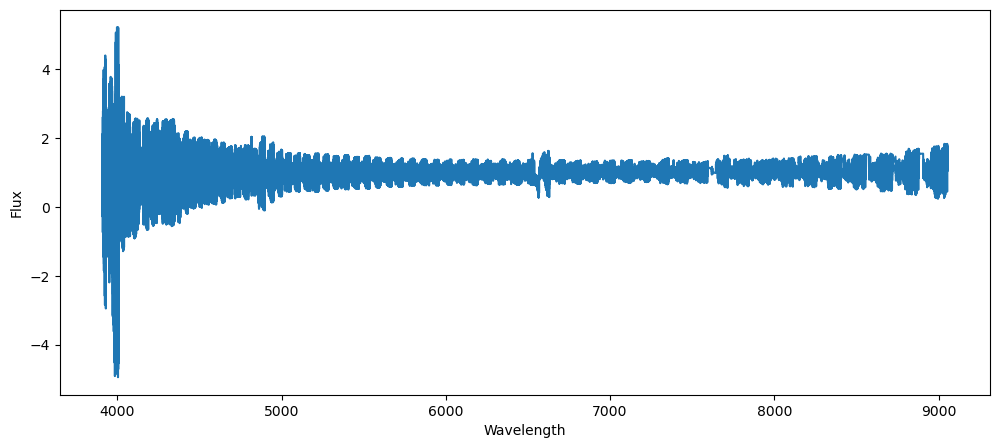

In [10]:

def readingAndReadyingData(fileAddress):
    hdul = fits.open(fileAddress)
    hdul.info()
    spec = hdul[1]
    print(spec.columns)
    data = hdul[1].data
    scifiber = hdul[0].header['SCIFIBER']
    print(scifiber)
    fig, ax = plt.subplots(figsize=(12, 5))
    
    allWavelengths = []
    allNormFlux = []
    for row in data:
        if row['fiber'] != scifiber:
            continue
        m = row['mask'] == 0
        good = (
        m &
        np.isfinite(row['normflux']) &
        np.isfinite(row['wavelength']) &
        (row['blaze'] > 0)
        )
        wavelengthsOfRow, fluxesOfRow = sigmaclipping(row['wavelength'][good],row['normflux'][good], 3, 0.000001, 15)
        allWavelengths.append(wavelengthsOfRow)
        allNormFlux.append(fluxesOfRow)
    
    
        np.set_printoptions(threshold=sys.maxsize)
        #print(row['blaze'])
        #ax.plot(row['wavelength'][good], (row['normflux'][good]))
    #combining and ordering everything
    allWavelengths = np.concatenate(allWavelengths)
    allNormFlux = np.concatenate(allNormFlux)
    ordering = np.argsort(allWavelengths)
    allWavelengths = allWavelengths[ordering]
    allNormFlux = allNormFlux[ordering]
    plt.plot(allWavelengths, allNormFlux)
    plt.xlabel("Wavelength")
    plt.ylabel("Flux")
test = r"C:\Users\nikli\Downloads\Comp Astro Project\lco_data-20260503-4 (2)\lco_data-20260503-4\tlvnrs04-fa18-20240120-0016-e92-1d.fits.fz"
readingAndReadyingData(test)